<center><h1>HW4</h1></center>
<br>
<br>

Name: xxx
<br>
Github Username: xxx
<br>
USC ID: xxx

## 1. Time Series Classification Part 1: Feature Creation/Extraction (HW3 Rerun)

### (a) Obtain Data

Import packages

In [132]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score,ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import EmpiricalCovariance
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from pathlib import Path
from scipy.stats import bootstrap
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold,cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
from itertools import cycle
from sklearn.preprocessing import label_binarize
from sklearn.metrics import auc as sklearn_auc
from sklearn.naive_bayes import GaussianNB, MultinomialNB


In [134]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import matplotlib
import statsmodels
import scipy

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, MultinomialNB

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("seaborn:", sns.__version__)
print("matplotlib:", matplotlib.__version__)
print("statsmodels:", statsmodels.__version__)
print("scipy:", scipy.__version__)

pandas: 2.3.3
numpy: 2.3.3
scikit-learn: 1.7.2
seaborn: 0.13.2
matplotlib: 3.10.6
statsmodels: 0.14.5
scipy: 1.16.2


Get the AReM Data Set

In [91]:
main_dir = Path("../data/AReM")
train_dfs = []
test_dfs = []
all_dfs = []##all data for dataset presentation in 1.c
ins = 0
for folder in main_dir.iterdir():
    index = 0#within one class
    if folder.is_dir():
 
        for file in folder.iterdir():
            index+=1
            if file.suffix == ".csv":
                ins+=1
                columns = ["time", "avg_rss12", "var_rss12", "avg_rss13", "var_rss13", "avg_rss23", "var_rss23"]
                try:
                    df = pd.read_csv(file, comment="#", names=columns)
                except Exception as e:
                    print(f"{folder.name}, {file.name}")
                    print(f"type of error: {type(e).__name__}")
                    print(f"details: {e}")
                df['class'] = folder.name
                df['instance'] = ins
                if folder.name in ['bending1','bending2']:
                    if index in [1,2]:
                        test_dfs.append(df)
                    else:
                        train_dfs.append(df)
                else:
                    if index in [1,2,3]:
                        test_dfs.append(df)
                    else:
                        train_dfs.append(df)  
                all_dfs.append(df)

### (b) Splitting Data

In [92]:
df_train = pd.concat(train_dfs, ignore_index=True)
df_test = pd.concat(test_dfs,ignore_index = True)
df_train##dataset 8 in sitting folder has only 479 rows

,time,avg_rss12,var_rss12,avg_rss13,var_rss13,avg_rss23,var_rss23,class,instance
0,0,42.00,0.71,21.25,0.43,30.00,0.00,bending1,3
1,250,41.50,0.50,20.25,1.48,31.25,1.09,bending1,3
2,500,41.50,0.50,14.25,1.92,33.00,0.00,bending1,3
3,750,40.75,0.83,15.75,0.43,33.00,0.00,bending1,3
4,1000,40.00,0.71,20.00,2.74,32.75,0.43,bending1,3
...,...,...,...,...,...,...,...,...,...
33114,118750,31.50,1.66,12.50,3.20,14.25,4.44,walking,88
33115,119000,27.33,1.25,11.33,0.94,20.00,4.00,walking,88
33116,119250,37.80,7.68,14.20,2.48,17.25,0.83,walking,88
33117,119500,33.75,1.30,15.75,5.21,16.50,2.69,walking,88


### (c) Feature Extraction

In [93]:
def quantile_1st(x):
    return x.quantile(0.25)
def quantile_3rd(x):
    return x.quantile(0.75)
df_all = pd.concat(all_dfs,ignore_index=True)
dataset = df_all.groupby('instance')[["avg_rss12", "var_rss12", "avg_rss13", "var_rss13", "avg_rss23", "var_rss23"]].agg(['min','max','mean','median','std',quantile_1st,quantile_3rd])
# dataset.columns
dataset.columns = [f'{col[1]}_{i//7+1}' for i, col in enumerate(dataset.columns)]
# minimum, maximum, mean, median, standard deviation, first quartile, and third quartile

#for train and test data feature extraction
df_train_agg = df_train.groupby('instance')[["avg_rss12", "var_rss12", "avg_rss13", "var_rss13", "avg_rss23", "var_rss23"]].agg(['min','max','mean','median','std',quantile_1st,quantile_3rd])
df_test_agg = df_test.groupby('instance')[["avg_rss12", "var_rss12", "avg_rss13", "var_rss13", "avg_rss23", "var_rss23"]].agg(['min','max','mean','median','std',quantile_1st,quantile_3rd])

df_train_agg.columns = [f'{col[1]}_{i//7+1}' for i, col in enumerate(df_train_agg.columns)]
df_test_agg.columns = [f'{col[1]}_{i//7+1}' for i, col in enumerate(df_test_agg.columns)]
# print(df_train_agg.columns)
df_train_f = df_train_agg.merge(df_train[['instance','class']].drop_duplicates(),
                              on = 'instance',how='left')
df_test_f = df_test_agg.merge(df_test[['instance','class']].drop_duplicates(),
                              on = 'instance',how='left')



In [94]:
df_train_f.shape[0]+df_test_f.shape[0]


88

In [95]:
df_train_f.head()

,instance,min_1,max_1,mean_1,median_1,std_1,quantile_1st_1,quantile_3rd_1,min_2,max_2,...,quantile_1st_5,quantile_3rd_5,min_6,max_6,mean_6,median_6,std_6,quantile_1st_6,quantile_3rd_6,class
0,3,35.00,47.40,43.954500,44.33,1.558835,43.00,45.00,0.0,1.70,...,35.3625,36.50,0.0,1.79,0.493292,0.43,0.513506,0.00,0.94,bending1
1,4,33.00,47.75,42.179813,43.50,3.670666,39.15,45.00,0.0,3.00,...,30.4575,36.33,0.0,2.18,0.613521,0.50,0.524317,0.00,1.00,bending1
2,5,33.00,45.75,41.678063,41.75,2.243490,41.33,42.75,0.0,2.83,...,28.4575,31.25,0.0,1.79,0.383292,0.43,0.389164,0.00,0.50,bending1
3,6,37.00,48.00,43.454958,43.25,1.386098,42.50,45.00,0.0,1.58,...,22.2500,24.00,0.0,5.26,0.679646,0.50,0.622534,0.43,0.87,bending1
4,7,36.25,48.00,43.969125,44.50,1.618364,43.31,44.67,0.0,1.50,...,20.5000,23.75,0.0,2.96,0.555312,0.49,0.487826,0.00,0.83,bending1


## 2. Time Series Classification Part 2: Binary and Multiclass Classification

### (a) Binary Classification Using Logistic Regression

#### i. Plots

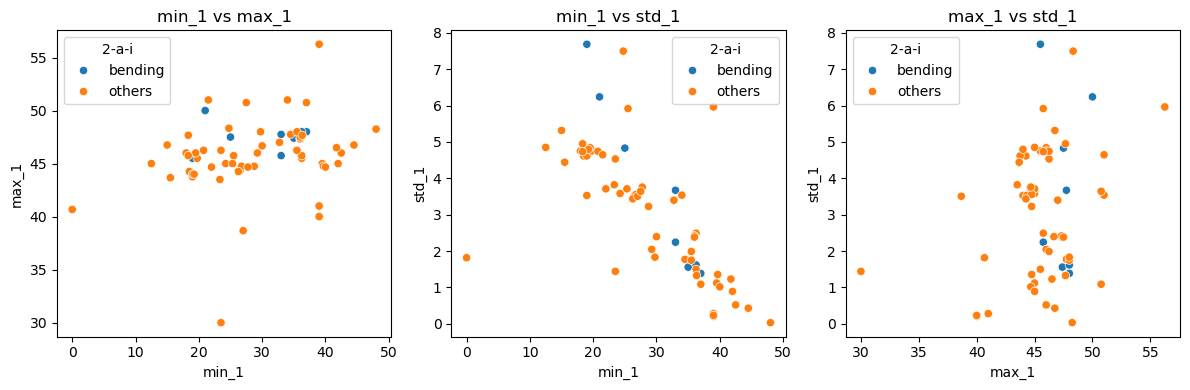

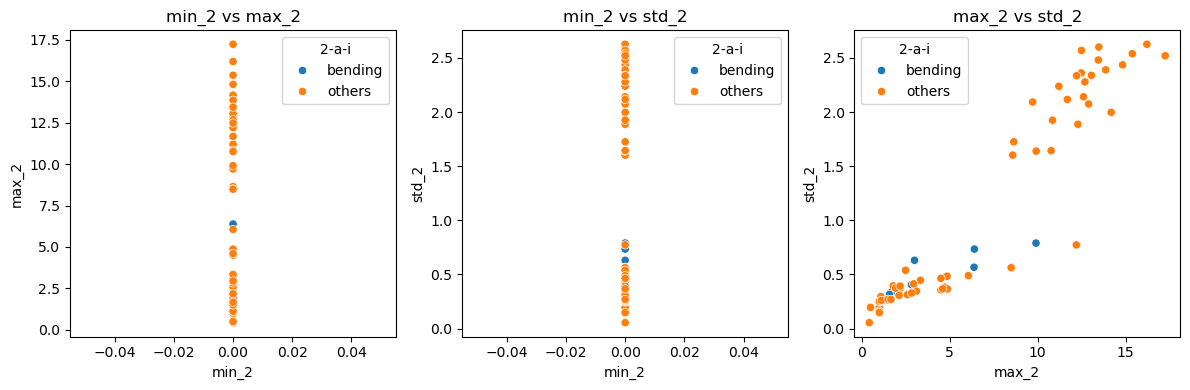

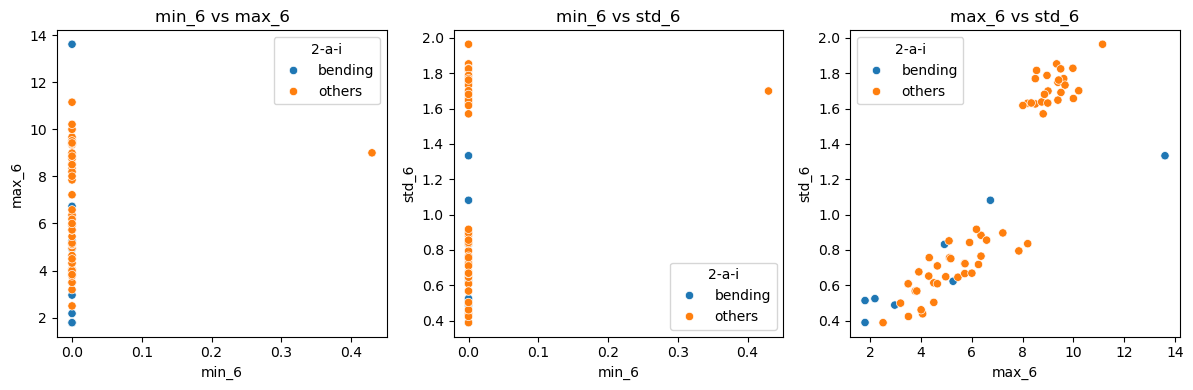

In [96]:
features = [
    ('min_1', 'max_1', 'std_1'), ('min_2', 'max_2', 'std_2'),
    ('min_6', 'max_6', 'std_6'),
]
df_train_f['2-a-i'] = df_train_f['class'].apply(lambda x: 'bending' if x == 'bending1' or x =='bending2' else 'others')


for f1, f2, f3 in features:
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    sns.scatterplot(data=df_train_f, x=f1, y=f2, hue='2-a-i')
    plt.title(f'{f1} vs {f2}')

    plt.subplot(1,3,2)
    sns.scatterplot(data=df_train_f, x=f1, y=f3, hue='2-a-i')
    plt.title(f'{f1} vs {f3}')

    plt.subplot(1,3,3)
    sns.scatterplot(data=df_train_f, x=f2, y=f3, hue='2-a-i')
    plt.title(f'{f2} vs {f3}')

    plt.tight_layout()
    plt.show()


#### ii. Splitted Plots

In [97]:
train_dfs_split = []

for instance_id, group in df_train.groupby("instance"):
    bound = len(group) // 2 
    first_half = group.iloc[:bound].copy()
    second_half = group.iloc[bound:].copy()
    first_half["part"] = 1
    second_half["part"] = 2
    combined = pd.concat([first_half, second_half], ignore_index=True)
    train_dfs_split.append(combined)
df_train_split = pd.concat(train_dfs_split, ignore_index=True)

df_2a_ii_1 = df_train_split[df_train_split['part'] == 1].copy()
df_2a_ii_2 = df_train_split[df_train_split['part'] == 2].copy()


df_2a_ii_1_a = df_2a_ii_1.groupby(['instance','part'])[["avg_rss12", "var_rss12", "avg_rss13", "var_rss13", "avg_rss23", "var_rss23"]].agg(['min','max','mean','median','std',quantile_1st,quantile_3rd])
df_2a_ii_1_a.columns = [f'{col[1]}_{i//7+1}' for i, col in enumerate(df_2a_ii_1_a.columns)]
df_2a_ii_1 = df_2a_ii_1_a.merge(df_2a_ii_1[['instance','class','part']].drop_duplicates(),
                              on = 'instance',how='left')

df_2a_ii_2_a = df_2a_ii_2.groupby(['instance','part'])[["avg_rss12", "var_rss12", "avg_rss13", "var_rss13", "avg_rss23", "var_rss23"]].agg(['min','max','mean','median','std',quantile_1st,quantile_3rd])
df_2a_ii_2_a.columns = [f'{col[1]}_{i//7+1}' for i, col in enumerate(df_2a_ii_2_a.columns)]
df_2a_ii_2 = df_2a_ii_2_a.merge(df_2a_ii_2[['instance','class','part']].drop_duplicates(),
                              on = 'instance',how='left')


## the first half

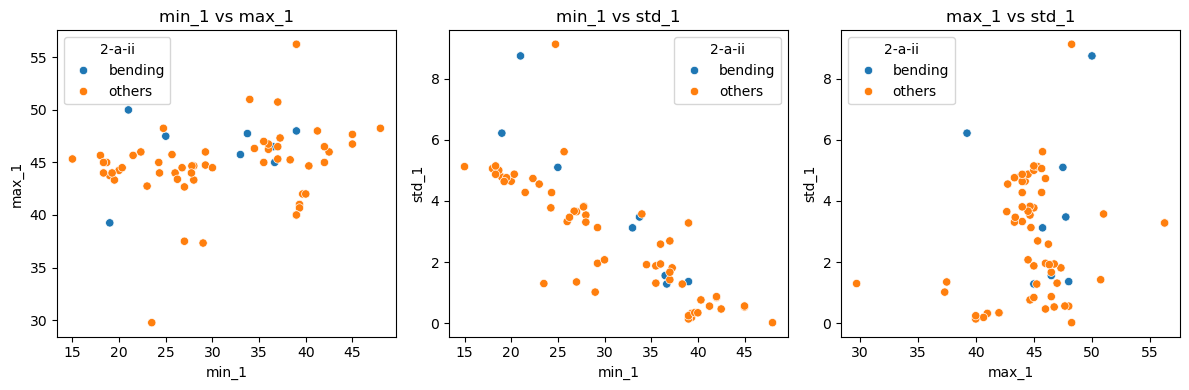

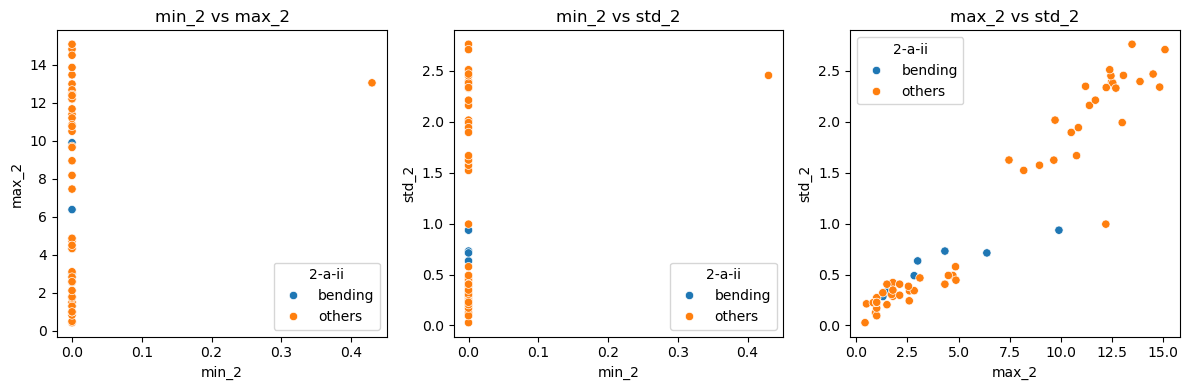

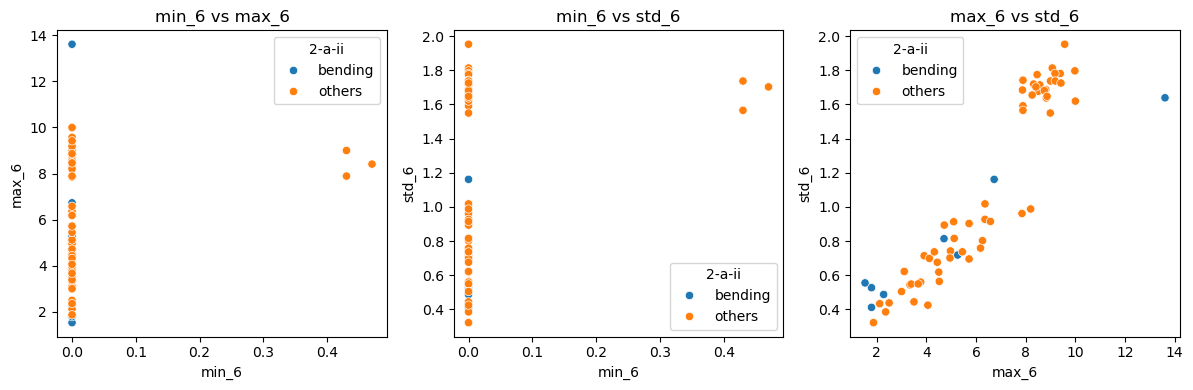

In [98]:
features = [
    ('min_1', 'max_1', 'std_1'), ('min_2', 'max_2', 'std_2'),
    ('min_6', 'max_6', 'std_6'),
]
df_2a_ii_1['2-a-ii'] = df_2a_ii_1['class'].apply(lambda x: 'bending' if x == 'bending1' or x =='bending2' else 'others')

for f1, f2, f3 in features:
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    sns.scatterplot(data=df_2a_ii_1, x=f1, y=f2, hue='2-a-ii')
    plt.title(f'{f1} vs {f2}')

    plt.subplot(1,3,2)
    sns.scatterplot(data=df_2a_ii_1, x=f1, y=f3, hue='2-a-ii')
    plt.title(f'{f1} vs {f3}')

    plt.subplot(1,3,3)
    sns.scatterplot(data=df_2a_ii_1, x=f2, y=f3, hue='2-a-ii')
    plt.title(f'{f2} vs {f3}')

    plt.tight_layout()
    plt.show()

## the last half

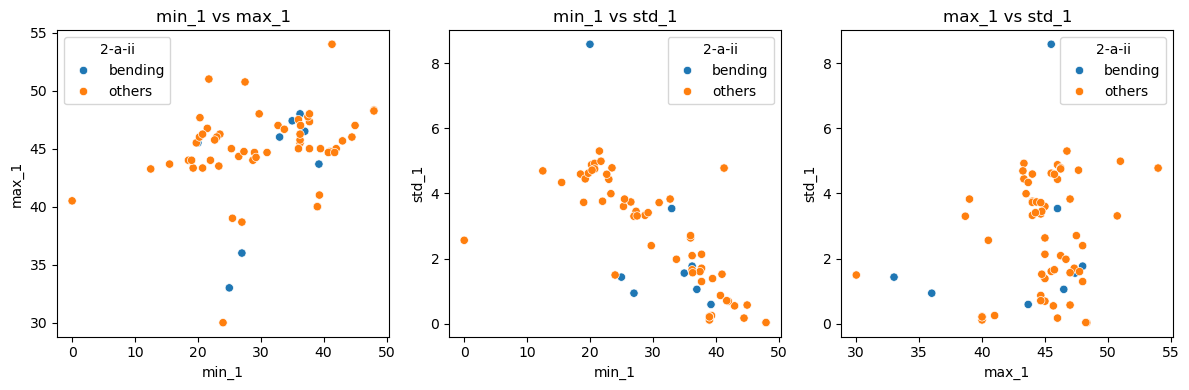

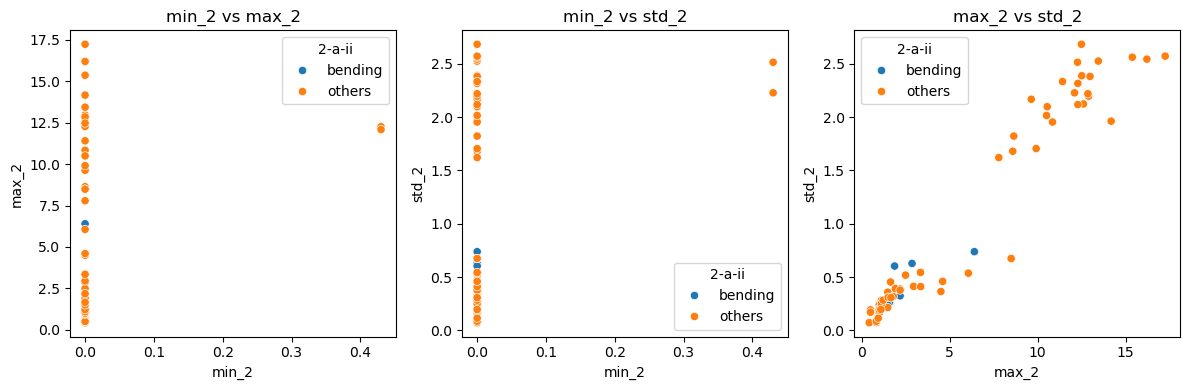

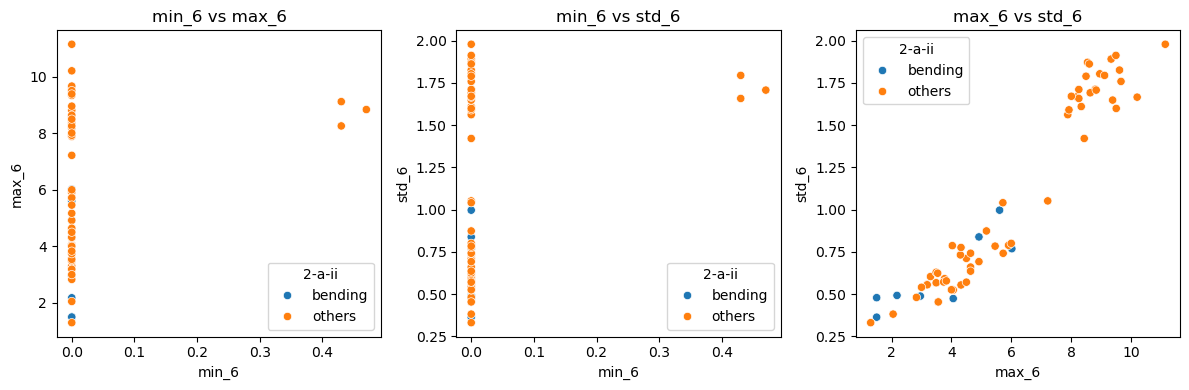

In [99]:
features = [
    ('min_1', 'max_1', 'std_1'), ('min_2', 'max_2', 'std_2'),
    ('min_6', 'max_6', 'std_6'),
]
df_2a_ii_2['2-a-ii'] = df_2a_ii_2['class'].apply(lambda x: 'bending' if x == 'bending1' or x =='bending2' else 'others')

for f1, f2, f3 in features:
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    sns.scatterplot(data=df_2a_ii_2, x=f1, y=f2, hue='2-a-ii')
    plt.title(f'{f1} vs {f2}')

    plt.subplot(1,3,2)
    sns.scatterplot(data=df_2a_ii_2, x=f1, y=f3, hue='2-a-ii')
    plt.title(f'{f1} vs {f3}')

    plt.subplot(1,3,3)
    sns.scatterplot(data=df_2a_ii_2, x=f2, y=f3, hue='2-a-ii')
    plt.title(f'{f2} vs {f3}')

    plt.tight_layout()
    plt.show()

## difference
No, i cannot see any considerable differences.

#### iii. Time Series Segments

## Explanation  
when choosing the predictors, it should be done in the train part of each fold, instead of the whole fold. Otherwise, the variable selection will use the labels of validation part of fold, which is leaking.

In [100]:
##split分段
def split(data,n):
    data = data.copy()
    results = []
    for instance_id, group in data.groupby("instance"):
        length = len(group) // n
        for i in range(n):
            start = i*length
            end = (i+1)* length if i<n-1 else len(group)
            subgroup = group[start:end].copy()
            subgroup['part'] = i+1
            results.append(subgroup)
    return pd.concat(results,ignore_index=True)

#feature合并，构建特征
def feature(data):
    data = data.copy()
    data_agg = data.groupby(['instance','part'])[["avg_rss12", 
                                                "var_rss12", "avg_rss13", "var_rss13", "avg_rss23",
                                                "var_rss23"]].agg(['min','max','std']).reset_index()
    data_wide = (
        data_agg
        .set_index(['instance','part'])
        .unstack(level='part')
    )
    data_wide.columns = [f'{col[0]}_{col[1]}_part_{col[2]}' for i,col in enumerate(data_wide.columns)]
    data = data_wide.merge(data[['instance','class']].drop_duplicates(),on='instance',how='left')
    return data
#find l,p
def find_best():
    best_score = -1
    bestL = None
    bestP = None

    L_list = list(range(1,21))

    for l in L_list:
        data = split(df_train,l)
        data = feature(data)
        data = data.dropna().reset_index(drop=True)
        # if l ==1:
        #     print(data.head())
        X = data.drop(columns=['instance','class'])
        Y = data['class'].apply(lambda x : 1 if x == 'bending1' or x == 'bending2' else 0)



        P_max = len(X.columns)
        P_list = np.linspace(5, P_max, num=min(5,P_max-5), dtype=int)

        for p in P_list:
            scaler = StandardScaler()
            model1 = LogisticRegression(max_iter=1000,solver='liblinear',penalty='l2', C=0.5)
            model2 = LogisticRegression(max_iter=1000,solver='liblinear',penalty='l2', C=0.5)
            rfe = RFE(estimator=model1, n_features_to_select=p)
            pipe = Pipeline([
                ('scaler', scaler),
                ('feature_selection', rfe),        
            ('clf', model2)                
            ])
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            scores = cross_val_score(pipe, X, Y, cv=cv)
            score_mean = np.mean(scores)
            # print(l,p)#t
            # print(scores,'/n',score_mean)#t
            if score_mean>best_score:
                best_score = score_mean
                bestL = l
                bestP = p
                # print('best')#t
    return bestL,bestP,best_score
#given L,P, obtain X,Y
def get_XY(data,p):
    data = data.dropna().reset_index(drop=True)
    X = data.drop(columns=['instance','class'])
    Y = data['class'].apply(lambda x : 1 if x == 'bending1' or x == 'bending2' else 0)
    model1 = LogisticRegression(max_iter=1000,solver='liblinear',penalty='l1', C=0.5)
    rfe = RFE(estimator=model1,n_features_to_select=p)
    rfe.fit(X,Y)
    x_columns = X.columns[rfe.support_]
    return X[x_columns],Y

In [101]:
L,P,score = find_best()

In [102]:
L,P,score

(4, np.int64(5), np.float64(0.9857142857142858))

In [103]:
train = split(df_train,L)
train = feature(train)
train = train.dropna().reset_index(drop=True)

##X and Y
X,Y = get_XY(train,P)
#model
model = LogisticRegression(max_iter=1000,solver='liblinear',penalty='l2', C=0.5)
model.fit(X,Y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.5
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


#### iv. Confusion Matrix

In [104]:
y_pred = model.predict(X)
cm = confusion_matrix(Y, y_pred)
print('confusion matrix')
cm

confusion matrix


array([[60,  0],
       [ 0,  8]])

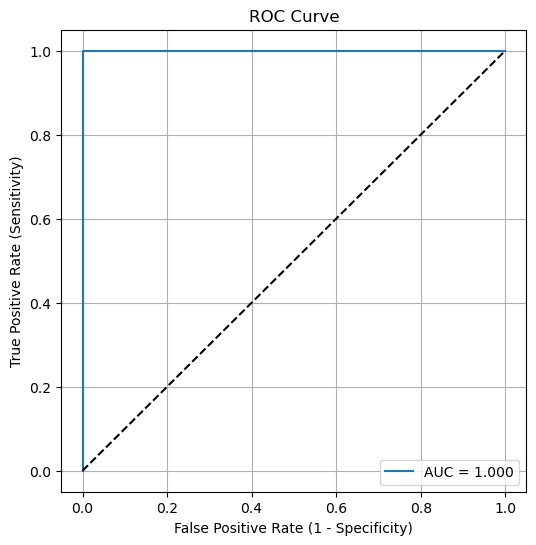

In [105]:
y_prob = model.predict_proba(X)[:, 1]
fpr, tpr, thresholds = roc_curve(Y, y_prob)
auc_score = roc_auc_score(Y, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [106]:
coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient (βi)': model.coef_[0]
}).sort_values(by='Coefficient (βi)')

print(coef)

                Feature  Coefficient (βi)
0  avg_rss12_max_part_1         -0.508723
4  var_rss23_max_part_3         -0.283200
1  var_rss12_max_part_1         -0.153766
2  avg_rss23_min_part_4          0.197865
3  avg_rss23_max_part_1          0.753262


In [107]:
X_const = sm.add_constant(X)  
model2 = sm.Logit(Y, X_const)
result = model2.fit_regularized(
    method='l1',
    alpha=3,       
    maxiter=1000
)


print(result.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.08168110173286929
            Iterations: 28
            Function evaluations: 35
            Gradient evaluations: 28
                           Logit Regression Results                           
Dep. Variable:                  class   No. Observations:                   68
Model:                          Logit   Df Residuals:                       63
Method:                           MLE   Df Model:                            4
Date:                Thu, 16 Oct 2025   Pseudo R-squ.:                  0.9231
Time:                        13:01:48   Log-Likelihood:                -1.8946
converged:                       True   LL-Null:                       -24.630
Covariance Type:            nonrobust   LLR p-value:                 3.173e-09
                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

#### v. Test Classifier

In [108]:
test = split(df_test,L)
test = feature(test)
test = test.dropna().reset_index(drop=True)
train = split(df_train,L)
train = feature(train)
train = train.dropna().reset_index(drop=True)

##X and Y train
X_train,Y_train = get_XY(train,P)
##X and Y test
X_test = test.drop(columns=['instance','class'])
Y_test = test['class'].apply(lambda x : 1 if x == 'bending1' or x == 'bending2' else 0)
X_test = X_test[X_train.columns]
#model
model = LogisticRegression(max_iter=1000,solver='liblinear',penalty='l2', C=0.5)
model.fit(X_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.5
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [109]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(Y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9473684210526315


## Answer
The accuary on the test set is lower than that on train set, 0.947 vs 0.9857

#### vi. Separation

Yes, as you see, the classifier can achieve 100% accuracy on train set, and no parameters are significant under 1% confidence

#### vii. Imbalance

answer
Yes, 8:60.

In [110]:
train = split(df_train,L)
train = feature(train)
train = train.dropna().reset_index(drop=True)
train['2a'] = train['class'].apply(lambda x:1 if x  == 'bending1' or x == 'bending2' else 0)
test = split(df_test,L)
test = feature(test)
test = test.dropna().reset_index(drop=True)
test['2a'] = test['class'].apply(lambda x:1 if x  == 'bending1' or x == 'bending2' else 0)
##case control data_2a is train data set
case = train[train['2a'] == 1]
control = train[train['2a'] == 0]
control_downsample  =resample(control,
                              replace = False,n_samples=len(case),random_state = 42)
data_2a = pd.concat([case,control_downsample])
data_2a = data_2a.sample(frac=1, random_state=42).reset_index(drop=True)
data_2a['2a'].mean()

np.float64(0.5)

In [111]:
##adjust para
pi = train['2a'].mean()
pi_hat = data_2a['2a'].mean()

#train
X = data_2a.drop(columns = ['instance','class','2a'])
Y = data_2a['2a']
model3  =LogisticRegression(max_iter=1000,solver='liblinear')
model3.fit(X,Y)
#test
X_test = test.drop(columns = ['instance','class','2a'])
Y_test = test['2a']
p = model3.predict_proba(X_test)[:,1]
adj = np.log((pi*(1-pi_hat))/(pi_hat*(1-pi)))
logit_p = np.log(p/(1-p))
logit_p = logit_p+adj

p_adj = 1/(1+np.exp(-logit_p))

In [112]:
y_pred = (p_adj>=0.5).astype(int)
Y_test = np.array(Y_test)
cm = confusion_matrix(Y_test,y_pred)
print('confusion matrix:')
print(cm)

confusion matrix:
[[15  0]
 [ 1  3]]


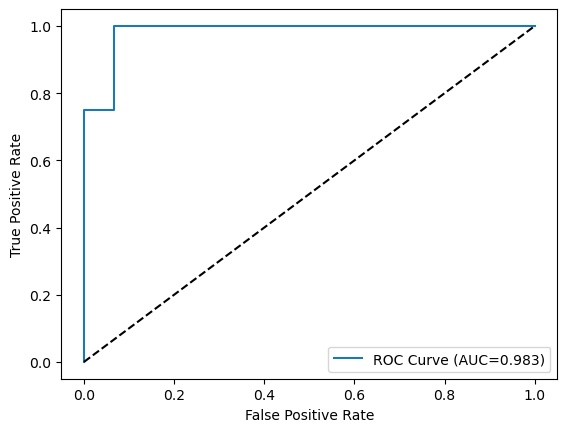

AUC Score: 0.9833333333333334


In [113]:
fpr, tpr, _ = roc_curve(Y_test, p_adj)
auc = roc_auc_score(Y_test, p_adj)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

print("AUC Score:", auc)

### (b) Binary Classification Using L1-penalized logistic regression

#### i. Time Series Segments

In [114]:
#find l,p
def find2_best():
    best_score = -1
    bestL = None
    bestC = None

    L_list = list(range(1,21))

    for l in L_list:
        data = split(df_train,l)
        data = feature(data)
        data = data.dropna().reset_index(drop=True)
        # if l ==1:
        #     print(data.head())
        X = data.drop(columns=['instance','class'])
        Y = data['class'].apply(lambda x : 1 if x == 'bending1' or x == 'bending2' else 0)



        C_list = [0.001, 0.01, 0.1, 1,5, 10]

        for c in C_list:
            model4=LogisticRegression(penalty='l1',solver='liblinear',C=c,max_iter=1000)
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            scores = cross_val_score(model4, X, Y, cv=cv, scoring='accuracy')
            score = np.mean(scores)
            if score>best_score:
                bestL = L
                bestC = c
                best_score = score
    return bestL,bestC,best_score
l,c,score = find2_best()
l,c,score

(4, 1, np.float64(0.9714285714285715))

In [115]:
test = split(df_test,L)
test = feature(test)
test = test.dropna().reset_index(drop=True)
train = split(df_train,L)
train = feature(train)
train = train.dropna().reset_index(drop=True)


##X and Y 
X_train = train.drop(columns=['instance','class'])
Y_train = train['class'].apply(lambda x : 1 if x == 'bending1' or x == 'bending2' else 0)
X_test = test.drop(columns=['instance','class'])
Y_test = test['class'].apply(lambda x : 1 if x == 'bending1' or x == 'bending2' else 0)
#model
model5 = LogisticRegression(max_iter=1000,solver='liblinear',penalty='l1',C = c)
model5.fit(X_train,Y_train)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [116]:
y_pred = model5.predict(X_test)
acc = accuracy_score(Y_test,y_pred)
print(acc)

1.0


#### ii. Comparison

It is much better than that of L2, 1 vs 0.9473

### (c) Multi-class Classification (The Realistic Case)

#### i. Time Series Segments

In [117]:
def find3_best():
    best_score = -1
    bestL = None
    bestC = None

    L_list = list(range(1,21))

    for l in L_list:
        data = split(df_train,l)
        data = feature(data)
        data = data.dropna().reset_index(drop=True)
        # if l ==1:
        #     print(data.head())
        X = data.drop(columns=['instance','class'])
        le = LabelEncoder()
        Y = le.fit_transform(data['class'])
        C_list = [0.001, 0.01, 0.1, 1, 5, 10]

        for c in C_list:
            model5=LogisticRegression(penalty='l1',solver='saga',C=c,max_iter=1000)
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
            scores = cross_val_score(model5, X, Y, cv=cv, scoring='accuracy')
            score = np.mean(scores)
            if score>best_score:
                bestL = L
                bestC = c
                best_score = score
    return bestL,bestC,best_score
L,C,score = find3_best()
L,C,score

c:\Users\20157\.conda\envs\001\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\20157\.conda\envs\001\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\20157\.conda\envs\001\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\20157\.conda\envs\001\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\20157\.conda\envs\001\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\20157\.

(4, 1, np.float64(0.8549450549450549))

In [118]:
#data
train = split(df_train,l)
train = feature(train)
train = train.dropna().reset_index(drop=True)
X_train = train.drop(columns=['instance','class'])
le = LabelEncoder()
Y_train = le.fit_transform(train['class'])

test = split(df_test,l)
test = feature(test)
test = test.dropna().reset_index(drop=True)
X_test = test.drop(columns=['instance','class'])
le = LabelEncoder()
Y_test = le.fit_transform(test['class'])


model5 = LogisticRegression(penalty='l1',solver='saga',C=C,max_iter=1000)
model5.fit(X_train,Y_train)
y_pred = model5.predict(X_test)



c:\Users\20157\.conda\envs\001\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [119]:
test_acc = accuracy_score(Y_test, y_pred)
test_error = 1 - test_acc
print('test error:{:.4f}'.format(test_error))

test error:0.1579


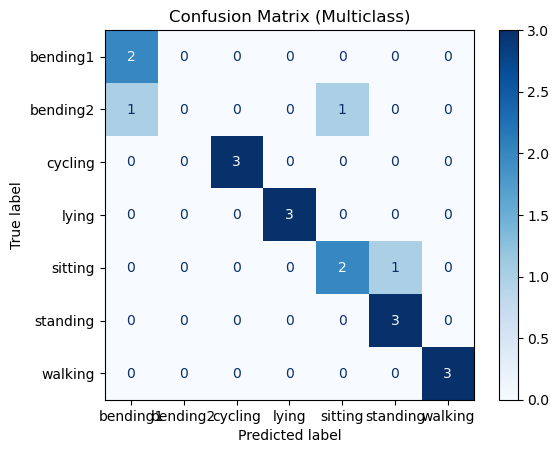

In [120]:
cm = confusion_matrix(Y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Multiclass)")
plt.show()

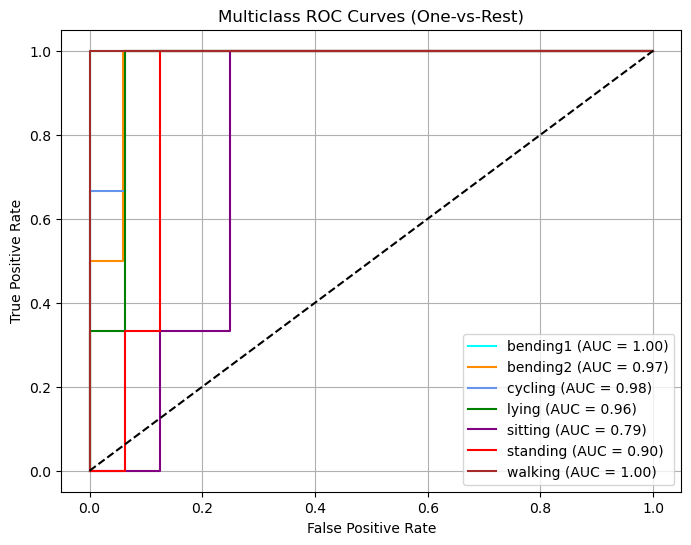

In [121]:
Y_test_bin = label_binarize(Y_test, classes=range(len(le.classes_)))
y_score = model5.decision_function(X_test)

fpr, tpr, roc_auc = {}, {}, {}
n_classes = Y_test_bin.shape[1]

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = sklearn_auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'purple', 'red', 'brown'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{le.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#### ii. Naive Bayes

In [122]:
def find4_best():
    best_score = -1
    bestL = None

    L_list = list(range(1,21))

    for l in L_list:
        data = split(df_train,l)
        data = feature(data)
        data = data.dropna().reset_index(drop=True)
        # if l ==1:
        #     print(data.head())
        X = data.drop(columns=['instance','class'])
        le = LabelEncoder()
        Y = le.fit_transform(data['class'])
        gnb=GaussianNB()
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(gnb, X, Y, cv=cv, scoring='accuracy')
        score = np.mean(scores)
        if score>best_score:
            bestL = L
            best_score = score
    return bestL,best_score
def find5_best():
    best_score = -1
    bestL = None
    bestC = None

    L_list = list(range(1,21))

    for l in L_list:
        data = split(df_train,l)
        data = feature(data)
        data = data.dropna().reset_index(drop=True)
        # if l ==1:
        #     print(data.head())
        X = data.drop(columns=['instance','class'])
        le = LabelEncoder()
        Y = le.fit_transform(data['class'])
        mnb = MultinomialNB()
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(mnb, X, Y, cv=cv, scoring='accuracy')
        score = np.mean(scores)
        if score>best_score:
            bestL = L
            best_score = score
    return bestL,best_score
L1,score1 = find4_best()
L2,score2 = find5_best()
print(L1,score1)
print(L2,score2)

c:\Users\20157\.conda\envs\001\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\20157\.conda\envs\001\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\20157\.conda\envs\001\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\20157\.conda\envs\001\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\20157\.conda\envs\001\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


4 0.8549450549450549
4 0.7934065934065934


### gaussian

In [123]:
train = split(df_train,l)
train = feature(train)
train = train.dropna().reset_index(drop=True)
X_train = train.drop(columns=['instance','class'])
le = LabelEncoder()
Y_train = le.fit_transform(train['class'])

test = split(df_test,l)
test = feature(test)
test = test.dropna().reset_index(drop=True)
X_test = test.drop(columns=['instance','class'])
le = LabelEncoder()
Y_test = le.fit_transform(test['class'])


gnb = GaussianNB()
gnb.fit(X_train,Y_train)
y_pred = gnb.predict(X_test)

In [124]:
test_acc = accuracy_score(Y_test, y_pred)
test_error = 1 - test_acc
print('test error:{:.4f}'.format(test_error))

test error:0.1579


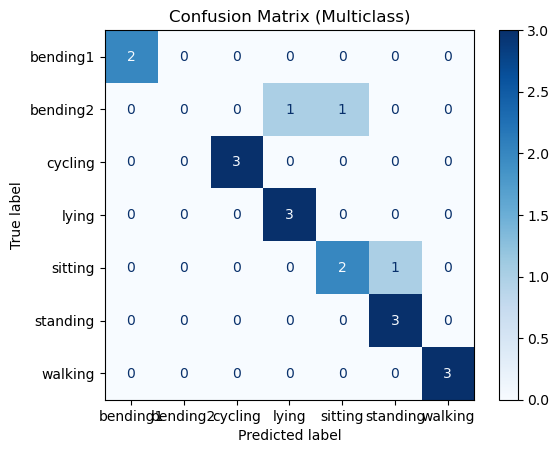

In [125]:
cm = confusion_matrix(Y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Multiclass)")
plt.show()

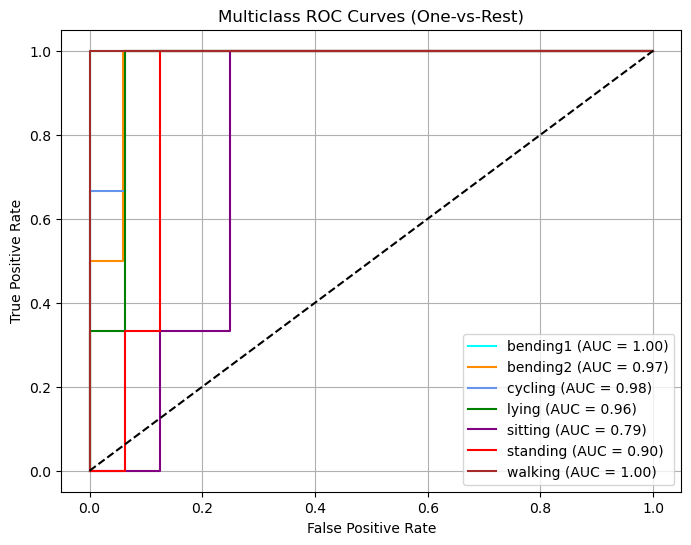

In [126]:
Y_test_bin = label_binarize(Y_test, classes=range(len(le.classes_)))
y_score = model5.decision_function(X_test)

fpr, tpr, roc_auc = {}, {}, {}
n_classes = Y_test_bin.shape[1]

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = sklearn_auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'purple', 'red', 'brown'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{le.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### multinomial

In [127]:
train = split(df_train,l)
train = feature(train)
train = train.dropna().reset_index(drop=True)
X_train = train.drop(columns=['instance','class'])
le = LabelEncoder()
Y_train = le.fit_transform(train['class'])

test = split(df_test,l)
test = feature(test)
test = test.dropna().reset_index(drop=True)
X_test = test.drop(columns=['instance','class'])
le = LabelEncoder()
Y_test = le.fit_transform(test['class'])


mnb = MultinomialNB()
mnb.fit(X_train,Y_train)
y_pred = mnb.predict(X_test)






In [128]:
test_acc = accuracy_score(Y_test, y_pred)
test_error = 1 - test_acc
print('test error:{:.4f}'.format(test_error))


test error:0.3158


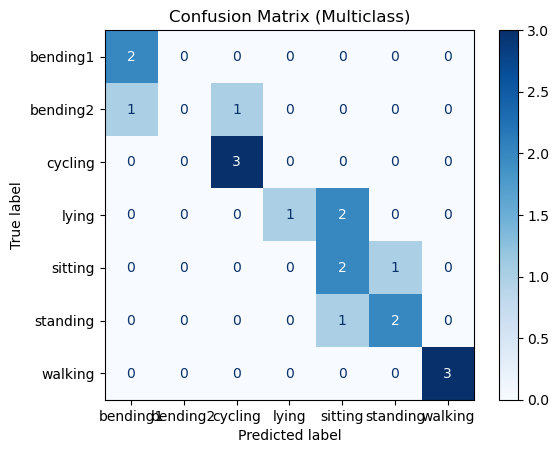

In [129]:
cm = confusion_matrix(Y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Multiclass)")
plt.show()

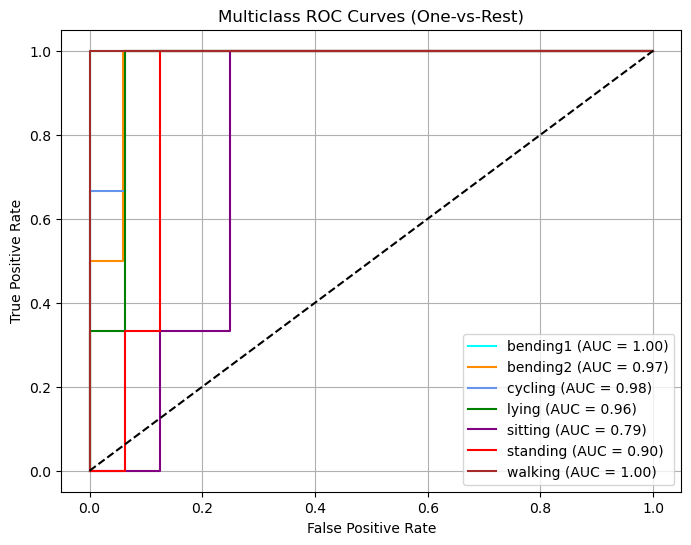

In [130]:
Y_test_bin = label_binarize(Y_test, classes=range(len(le.classes_)))
y_score = model5.decision_function(X_test)

fpr, tpr, roc_auc = {}, {}, {}
n_classes = Y_test_bin.shape[1]

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = sklearn_auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'purple', 'red', 'brown'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{le.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#### ii. Comparison

L1 Logistic regression and Gaussian naive Bayes are the same good, whose test errors are all 0.1579, and auc are the same for each class

## 3. ISLR 4.8.3

So, we have k classes, if one belongs to class k, then it follows this:X∣Y=k∼N(μk​,σk2​). the pdf is 
$$
f_k(x) = \frac{1}{\sqrt{2\pi}\,\sigma_k} \exp\!\left(-\frac{(x - \mu_k)^2}{2\sigma_k^2}\right)
$$
The discriminant function is 
$$
g_k(x) = \log(\pi_k f_k(x))
= \log \pi_k
- \tfrac{1}{2}\log(2\pi)
- \log \sigma_k
- \frac{(x - \mu_k)^2}{2\sigma_k^2}.
$$
express the squared term, and igonring log2pi, and we find it is quadratic about x.
$$
g_k(x) = -\frac{x^2}{2\sigma_k^2}
+ \frac{\mu_k}{\sigma_k^2}x
- \frac{\mu_k^2}{2\sigma_k^2}
+ \log \pi_k - \log \sigma_k
$$

## 4. ISLR 4.8.7

We know,

$$
f_{\text{Yes}}(x) = \frac{1}{\sqrt{2\pi(36)}} 
\exp\!\left(-\frac{(x - 10)^2}{2(36)}\right)
$$

and,
$$
f_{\text{No}}(x) = \frac{1}{\sqrt{2\pi(36)}} 
\exp\!\left(-\frac{(x - 0)^2}{2(36)}\right)
$$
then, we use bayes rule,
$$
P(\text{Yes} \mid X = 4)
= \frac{P(\text{Yes}) f_{\text{Yes}}(4)}
{P(\text{Yes}) f_{\text{Yes}}(4) + P(\text{No}) f_{\text{No}}(4)}
$$
finally, 
it is around 0.752

## 5.1. Extra Practice ISLR 4.8.4

## 5.2. Extra Practice ISLR 4.8.9